In [109]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

In [110]:
df = pd.read_csv('Travel.csv')

# Display the first 5 rows
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Data cleaning

In [111]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [112]:
df["Gender"].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [113]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [114]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [115]:
df["Gender"]=df["Gender"].replace("Fe Male","Female")
df["MaritalStatus"]=df["MaritalStatus"].replace("Unmarried","Single")

In [116]:
df["Gender"].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [117]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

In [118]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [119]:
#Missing value
features_with_na=[col for col in df.columns if df[col].isnull().sum()>0]
for feature in features_with_na:
    print(feature,round(df[feature].isnull().mean()*100,2),"% percent is missing ")


Age 4.62 % percent is missing 
TypeofContact 0.51 % percent is missing 
DurationOfPitch 5.14 % percent is missing 
NumberOfFollowups 0.92 % percent is missing 
PreferredPropertyStar 0.53 % percent is missing 
NumberOfTrips 2.86 % percent is missing 
NumberOfChildrenVisiting 1.35 % percent is missing 
MonthlyIncome 4.77 % percent is missing 


In [120]:
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Feature Engineering

In [121]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


## Exploratory Data Analysis
The following plots show individual feature distributions, relationships with the target, and whether the target classes are balanced.

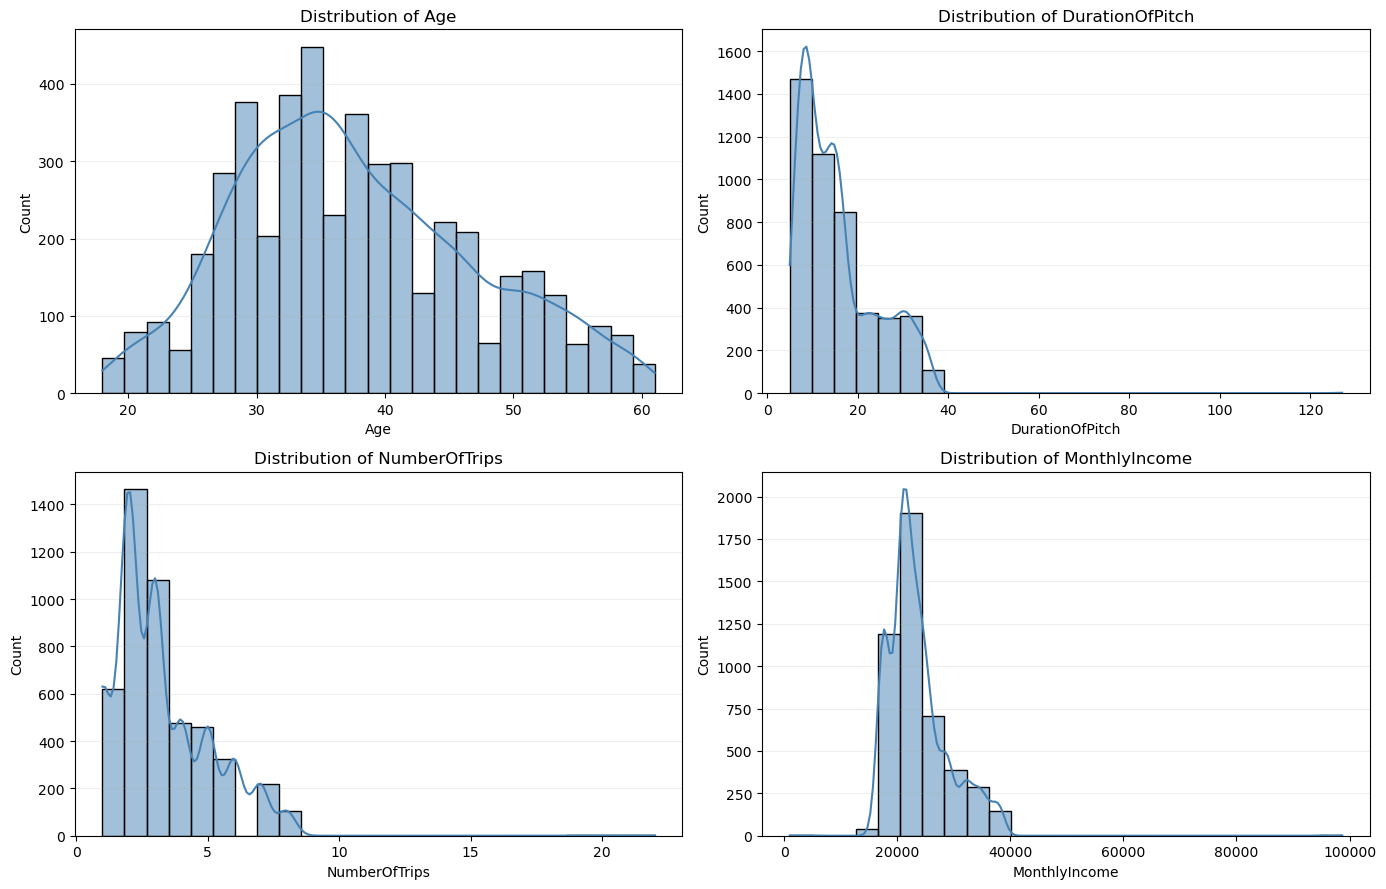

In [122]:
# Univariate analysis: distributions of important numerical features
univariate_features = ['Age', 'DurationOfPitch', 'NumberOfTrips', 'MonthlyIncome']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for feature, ax in zip(univariate_features, axes.flat):
    sns.histplot(data=df, x=feature, kde=True, bins=25, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

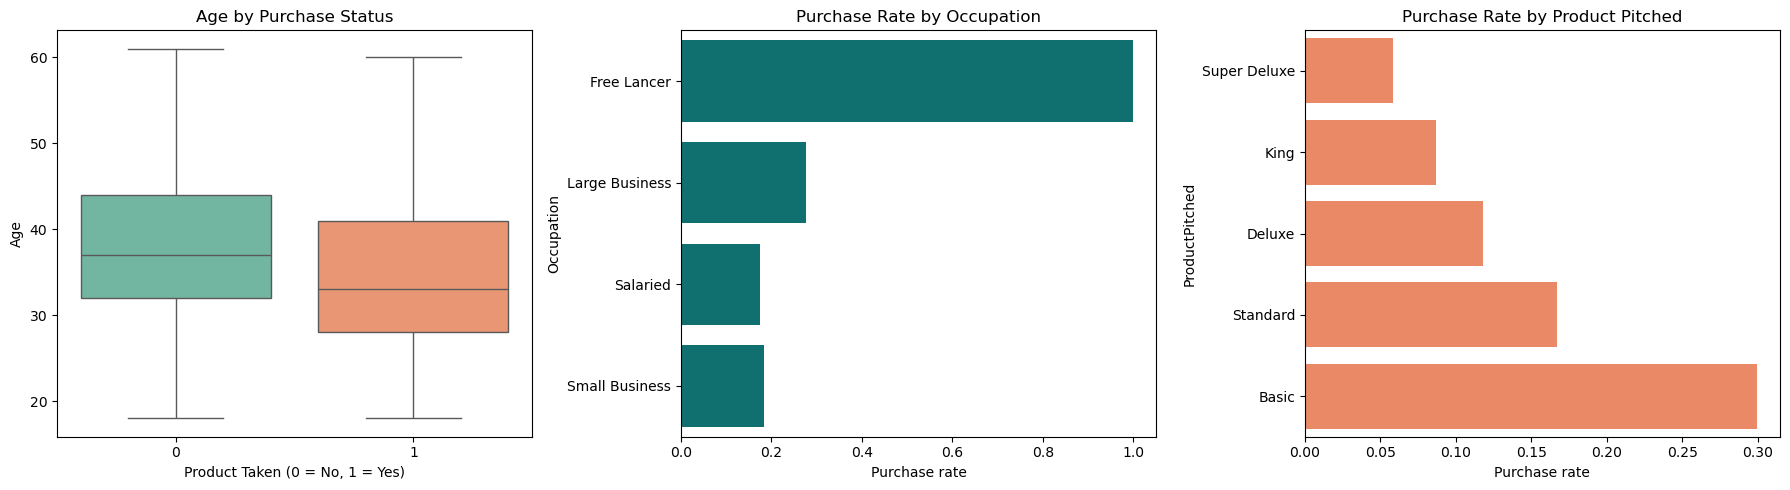

In [123]:
# Bivariate analysis: how selected features relate to product purchase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='ProdTaken', y='Age', ax=axes[0], palette='Set2')
axes[0].set_title('Age by Purchase Status')
axes[0].set_xlabel('Product Taken (0 = No, 1 = Yes)')

occupation_rate = df.groupby('Occupation', as_index=False)['ProdTaken'].mean()
sns.barplot(data=occupation_rate, x='ProdTaken', y='Occupation', ax=axes[1], color='teal')
axes[1].set_title('Purchase Rate by Occupation')
axes[1].set_xlabel('Purchase rate')

product_rate = df.groupby('ProductPitched', as_index=False)['ProdTaken'].mean().sort_values('ProdTaken')
sns.barplot(data=product_rate, x='ProdTaken', y='ProductPitched', ax=axes[2], color='coral')
axes[2].set_title('Purchase Rate by Product Pitched')
axes[2].set_xlabel('Purchase rate')

plt.tight_layout()
plt.show()

,count,percentage
ProdTaken,,
Not Taken,3968,81.18
Taken,920,18.82


Majority-to-minority imbalance ratio: 4.31:1


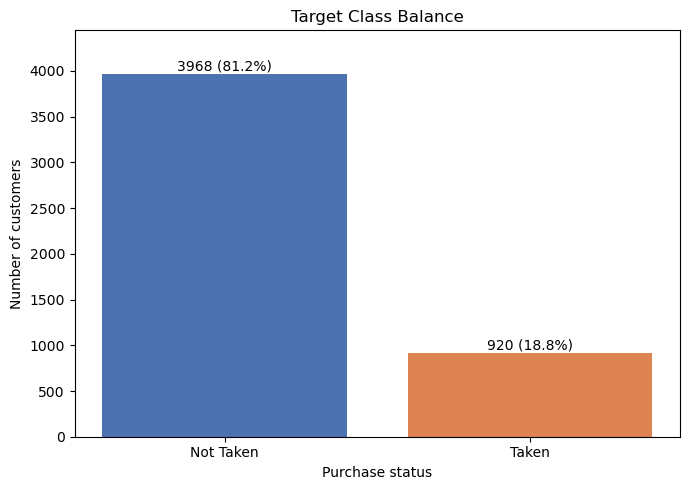

The target is imbalanced; use stratified splitting and imbalance-aware metrics.


In [124]:
# Class balance / imbalance analysis
class_counts = df['ProdTaken'].value_counts().sort_index()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)
imbalance_ratio = class_counts.max() / class_counts.min()

class_summary = pd.DataFrame({
    'count': class_counts,
    'percentage': class_percentages
}).rename(index={0: 'Not Taken', 1: 'Taken'})
display(class_summary)
print(f'Majority-to-minority imbalance ratio: {imbalance_ratio:.2f}:1')

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_summary.index, class_summary['count'], color=['#4C72B0', '#DD8452'])
for bar, percentage in zip(bars, class_summary['percentage']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{int(bar.get_height())} ({percentage:.1f}%)',
            ha='center', va='bottom')
ax.set_title('Target Class Balance')
ax.set_xlabel('Purchase status')
ax.set_ylabel('Number of customers')
ax.set_ylim(0, class_summary['count'].max() * 1.12)
plt.tight_layout()
plt.show()

if imbalance_ratio >= 1.5:
    print('The target is imbalanced; use stratified splitting and imbalance-aware metrics.')
else:
    print('The target classes are reasonably balanced.')

In [125]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['ProdTaken', 'CustomerID'])
y = df['ProdTaken']

In [126]:
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((3910, 18), (978, 18))

In [127]:
# Median imputation
median_features = [
    'Age',
    'DurationOfPitch',
    'NumberOfTrips',
    'MonthlyIncome'
]

# Mode imputation
mode_features = [
    'TypeofContact',
    'NumberOfFollowups',
    'PreferredPropertyStar',
    'NumberOfChildrenVisiting'
]

# Categorical and numerical features
cat_features = X.select_dtypes(include="object").columns.tolist()

num_features = X.select_dtypes(exclude="object").columns.tolist()

# Remaining numerical features
other_num_features = [
    col for col in num_features
    if col not in median_features + mode_features
]

In [128]:
# Median imputation + scaling
median_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Mode imputation + scaling for discrete numerical features
mode_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler())
    ]
)

# Mode imputation + OneHotEncoder
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ))
    ]
)

# Scaling for remaining numerical features
numeric_transformer = StandardScaler()

In [129]:
preprocessor = ColumnTransformer(
    transformers=[
        ("median", median_transformer, median_features),
        ("mode", mode_transformer, [
            col for col in mode_features
            if col in num_features
        ]),
        ("OneHotEncoder", categorical_transformer, cat_features),
        ("StandardScaler", numeric_transformer, other_num_features)
    ]
)

In [130]:
# Preview the processed training data without replacing the original features
X_train_processed = preprocessor.fit_transform(X_train)

# Convert to DataFrame
X_train_processed = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

X_train_processed.head()

,median__Age,median__DurationOfPitch,median__NumberOfTrips,median__MonthlyIncome,mode__NumberOfFollowups,mode__PreferredPropertyStar,mode__NumberOfChildrenVisiting,OneHotEncoder__TypeofContact_Self Enquiry,OneHotEncoder__Occupation_Large Business,OneHotEncoder__Occupation_Salaried,...,OneHotEncoder__MaritalStatus_Single,OneHotEncoder__Designation_Executive,OneHotEncoder__Designation_Manager,OneHotEncoder__Designation_Senior Manager,OneHotEncoder__Designation_VP,StandardScaler__CityTier,StandardScaler__NumberOfPersonVisiting,StandardScaler__Passport,StandardScaler__PitchSatisfactionScore,StandardScaler__OwnCar
0,-0.173791,-1.116889,-0.673593,-0.238806,-2.708464,1.775141,-1.379190,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.477328,-1.256729,-0.64351,0.670552,-1.279276
1,-0.173791,-0.879814,-0.673593,-0.959368,-0.708068,-0.729659,0.964414,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,-0.711099,0.128223,-0.64351,1.401078,-1.279276
2,-0.283409,-0.642739,-0.673593,0.542337,0.292129,-0.729659,-0.207388,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,-0.711099,0.128223,-0.64351,-0.790500,0.781692
3,0.045445,1.253859,1.518913,-0.351099,0.292129,0.522741,0.964414,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,-0.711099,1.513175,-0.64351,0.670552,-1.279276
4,0.045445,-1.116889,0.422660,-1.121296,-0.708068,1.775141,-0.207388,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,-0.711099,-1.256729,-0.64351,-0.790500,0.781692


In [131]:
# Preview the processed test data without replacing the original features
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame
X_test_processed = pd.DataFrame(
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed,
    columns=preprocessor.get_feature_names_out()
)

X_test_processed.head()

,median__Age,median__DurationOfPitch,median__NumberOfTrips,median__MonthlyIncome,mode__NumberOfFollowups,mode__PreferredPropertyStar,mode__NumberOfChildrenVisiting,OneHotEncoder__TypeofContact_Self Enquiry,OneHotEncoder__Occupation_Large Business,OneHotEncoder__Occupation_Salaried,...,OneHotEncoder__MaritalStatus_Single,OneHotEncoder__Designation_Executive,OneHotEncoder__Designation_Manager,OneHotEncoder__Designation_Senior Manager,OneHotEncoder__Designation_VP,StandardScaler__CityTier,StandardScaler__NumberOfPersonVisiting,StandardScaler__Passport,StandardScaler__PitchSatisfactionScore,StandardScaler__OwnCar
0,-0.393028,-0.998351,-0.125466,-0.414512,0.292129,-0.729659,-0.207388,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,-0.711099,1.513175,1.553978,-0.059974,0.781692
1,-0.173791,0.305560,-1.221719,0.056175,0.292129,-0.729659,-1.379190,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,-0.711099,-1.256729,-0.643510,-0.790500,0.781692
2,-0.612264,0.068485,-0.673593,-0.483397,1.292327,1.775141,0.964414,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,-0.711099,0.128223,1.553978,-0.059974,-1.279276
3,-0.831501,-0.168590,0.970787,-0.532278,0.292129,1.775141,-0.207388,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,-0.711099,0.128223,-0.643510,0.670552,-1.279276
4,-1.160356,-0.287127,-1.221719,-0.238806,-0.708068,-0.729659,-0.207388,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.477328,-1.256729,-0.643510,-0.059974,-1.279276


## Random Forest and Logistic Regression

In [132]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate

In [133]:
# Keep preprocessing and the classifier together to prevent data leakage
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('median', ...), ('mode', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [134]:
# Use the same class proportions in every validation fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

rf_cv_results = cross_validate(
    random_forest_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
)

rf_cv_scores = pd.DataFrame({
    'Accuracy': rf_cv_results['test_accuracy'],
    'Precision': rf_cv_results['test_precision'],
    'Recall': rf_cv_results['test_recall'],
    'F1 score': rf_cv_results['test_f1'],
    'ROC AUC': rf_cv_results['test_roc_auc']
})
rf_cv_summary = rf_cv_scores.agg(['mean', 'std']).T
rf_cv_summary.round(4)

,mean,std
Accuracy,0.9087,0.0087
Precision,0.9362,0.0382
Recall,0.5530,0.0302
F1 score,0.6950,0.0301
ROC AUC,0.9629,0.0105


In [135]:
# Train the final model on all training rows
random_forest_pipeline.fit(X_train, y_train)

rf_pred = random_forest_pipeline.predict(X_test)
rf_probability = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_test_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1 score': f1_score(y_test, rf_pred),
    'ROC AUC': roc_auc_score(y_test, rf_probability)
}, name='Test score')

display(rf_test_metrics.to_frame().round(4))
print(classification_report(y_test, rf_pred, target_names=['Not Taken', 'Taken']))

,Test score
Accuracy,0.9315
Precision,0.9756
Recall,0.6522
F1 score,0.7818
ROC AUC,0.9658


              precision    recall  f1-score   support

   Not Taken       0.93      1.00      0.96       794
       Taken       0.98      0.65      0.78       184

    accuracy                           0.93       978
   macro avg       0.95      0.82      0.87       978
weighted avg       0.93      0.93      0.93       978



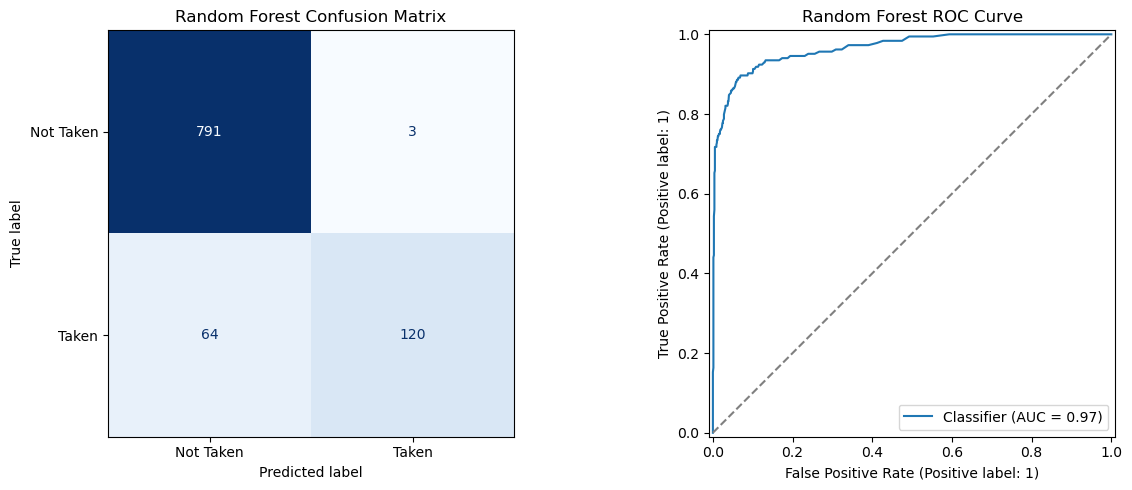

In [136]:
# Review classification errors and probability performance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['Not Taken', 'Taken'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Random Forest Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, rf_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_title('Random Forest ROC Curve')

plt.tight_layout()
plt.show()

### Logistic Regression

In [137]:
# Create the Logistic Regression pipeline
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('median', ...), ('mode', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [138]:
# Check Logistic Regression with five-fold cross-validation
logistic_cv_results = cross_validate(
    logistic_pipeline, X_train, y_train,
    cv=cv, scoring=scoring, n_jobs=-1
)

logistic_cv_scores = pd.DataFrame({
    'Accuracy': logistic_cv_results['test_accuracy'],
    'Precision': logistic_cv_results['test_precision'],
    'Recall': logistic_cv_results['test_recall'],
    'F1 score': logistic_cv_results['test_f1'],
    'ROC AUC': logistic_cv_results['test_roc_auc']
})
logistic_cv_summary = logistic_cv_scores.agg(['mean', 'std']).T

logistic_cv_summary.round(4)

,mean,std
Accuracy,0.7501,0.0234
Precision,0.4108,0.0292
Recall,0.7460,0.0391
F1 score,0.5297,0.0326
ROC AUC,0.8184,0.0205


In [139]:
# Train and test Logistic Regression
logistic_pipeline.fit(X_train, y_train)

logistic_pred = logistic_pipeline.predict(X_test)
logistic_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_test_metrics = pd.Series({
    'Accuracy': accuracy_score(y_test, logistic_pred),
    'Precision': precision_score(y_test, logistic_pred),
    'Recall': recall_score(y_test, logistic_pred),
    'F1 score': f1_score(y_test, logistic_pred),
    'ROC AUC': roc_auc_score(y_test, logistic_probability)
}, name='Test score')

display(logistic_test_metrics.to_frame().round(4))
print(classification_report(y_test, logistic_pred, target_names=['Not Taken', 'Taken']))

,Test score
Accuracy,0.7249
Precision,0.3739
Recall,0.6848
F1 score,0.4837
ROC AUC,0.7679


              precision    recall  f1-score   support

   Not Taken       0.91      0.73      0.81       794
       Taken       0.37      0.68      0.48       184

    accuracy                           0.72       978
   macro avg       0.64      0.71      0.65       978
weighted avg       0.81      0.72      0.75       978



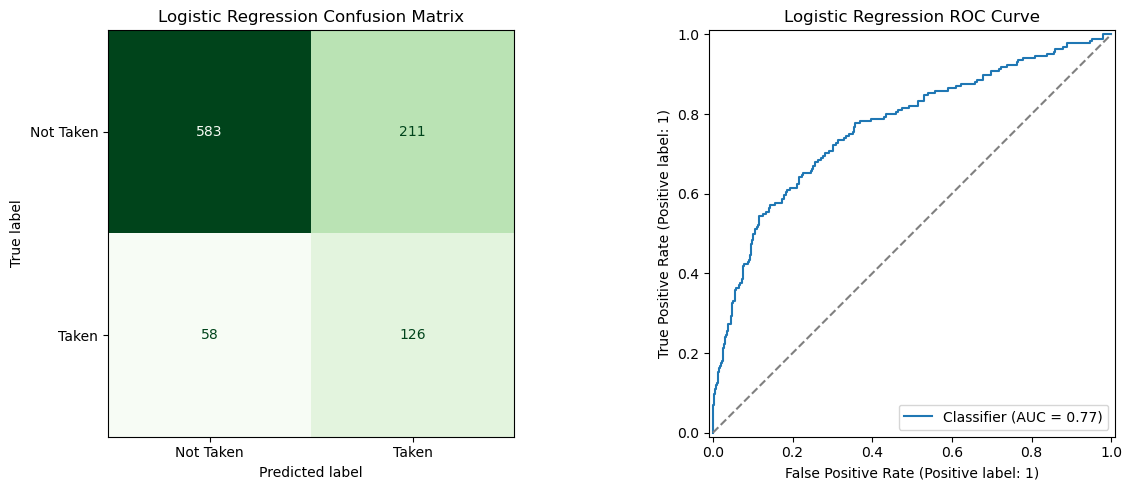

In [140]:
# Plot Logistic Regression results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, logistic_pred, display_labels=['Not Taken', 'Taken'],
    cmap='Greens', ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, logistic_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[1].set_title('Logistic Regression ROC Curve')

plt.tight_layout()
plt.show()

In [141]:
# Compare both models on the test data
model_comparison = pd.DataFrame({
    'Random Forest': rf_test_metrics,
    'Logistic Regression': logistic_test_metrics
})

model_comparison.round(4)

,Random Forest,Logistic Regression
Accuracy,0.9315,0.7249
Precision,0.9756,0.3739
Recall,0.6522,0.6848
F1 score,0.7818,0.4837
ROC AUC,0.9658,0.7679


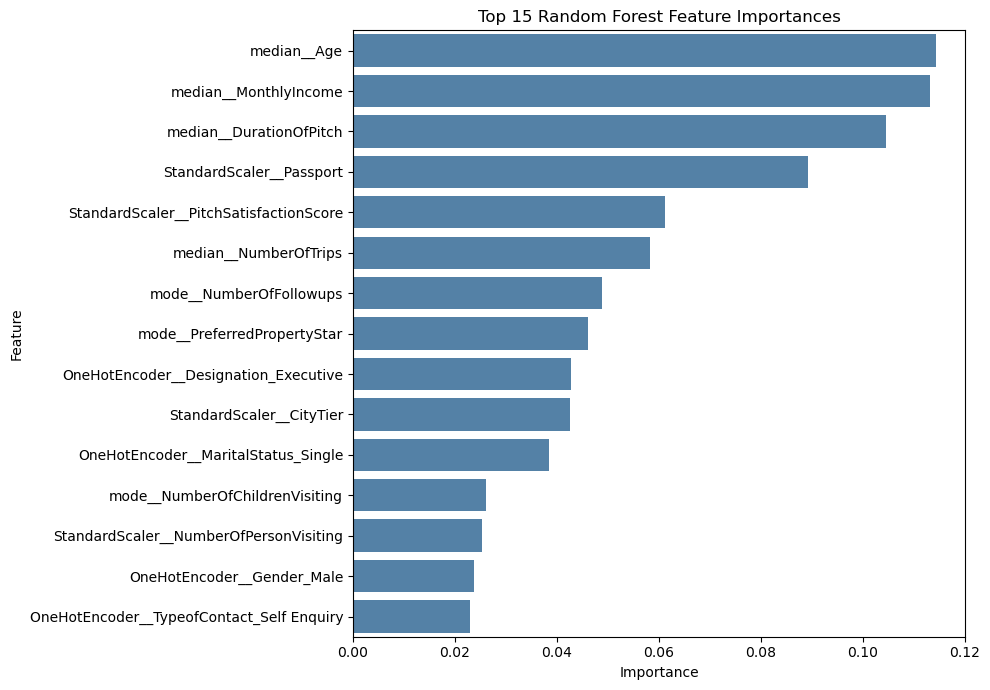

In [142]:
# Display the features that contribute most to the model
feature_names = random_forest_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.Series(
    random_forest_pipeline.named_steps['classifier'].feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color='steelblue')
plt.title('Top 15 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()